# 🎭 Notebook 6: Multi-Head Attention

**Multiple Perspectives on the Same Sequence**

---

## 🎯 Learning Objectives

By the end of this notebook, you will:

1. Understand **why multiple heads** are needed
2. Implement **parallel attention heads**
3. Learn **concatenation and projection**
4. Visualize **different attention patterns**
5. Build a complete **Multi-Head Attention layer**
6. Understand **computational efficiency**

---

## 📚 Table of Contents

1. [The Single Head Limitation](#1-the-single-head-limitation)
2. [Multi-Head Intuition](#2-multi-head-intuition)
3. [Parallel Attention Heads](#3-parallel-attention-heads)
4. [Concatenation & Projection](#4-concatenation-projection)
5. [Complete Multi-Head Attention](#5-complete-multi-head-attention)
6. [Attention Pattern Visualization](#6-attention-pattern-visualization)
7. [Computational Analysis](#7-computational-analysis)
8. [Key Takeaways](#8-key-takeaways)

In [25]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

print("✅ Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

✅ Libraries imported successfully!
PyTorch version: 2.10.0+cpu


### Environment Setup (Colab/Local)

This cell detects whether you're running in Google Colab or locally and sets up the environment accordingly.

In [26]:
# ========================================
# ENVIRONMENT DETECTION & SETUP
# ========================================

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running locally")

# Setup directories
if IN_COLAB:
    # Create necessary directories for Colab
    os.makedirs('data', exist_ok=True)
    os.makedirs('visualizations/tokenization', exist_ok=True)
    os.makedirs('visualizations/embeddings', exist_ok=True)
    os.makedirs('visualizations/data_pipeline', exist_ok=True)
    print("Created directories")
    
    # Set paths for Colab
    DATA_DIR = 'data'
    VIZ_DIR = 'visualizations'
else:
    # Use relative paths for local execution
    DATA_DIR = '../data'
    VIZ_DIR = '../visualizations'
    
    # Create directories if they don't exist (LOCAL FIX)
    os.makedirs(DATA_DIR, exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/tokenization', exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/embeddings', exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/data_pipeline', exist_ok=True)
    print(f"Created directories: {DATA_DIR}, {VIZ_DIR}")

print(f"\nData directory: {DATA_DIR}")
print(f"Visualization directory: {VIZ_DIR}")

Running in Google Colab
Created directories

Data directory: data
Visualization directory: visualizations


In [27]:
# ========================================
# LOAD OR GENERATE CONFIGURATION
# ========================================
# This cell loads config from previous notebooks if available,
# or generates it from scratch so notebook 05 works standalone on Colab.

import urllib.request

config_path    = f'{DATA_DIR}/data_config.pkl'
embedding_path = f'{DATA_DIR}/embedding_layer.pth'

if os.path.exists(config_path) and os.path.exists(embedding_path):
    # ── Files exist: load from previous notebooks ──────────────────
    with open(config_path, 'rb') as f:
        config = pickle.load(f)
    vocab_size = config['vocab_size']
    block_size = config['block_size']
    batch_size = config['batch_size']

    checkpoint = torch.load(embedding_path, map_location='cpu')
    n_embd = checkpoint['n_embd']
    print('✅ Loaded configuration from previous notebooks')

else:
    # ── Files missing: generate from scratch ───────────────────────
    print('⚠️  Previous notebook files not found — generating from scratch...')

    # Default hyperparameters (same as notebook 04)
    block_size = 8
    batch_size = 4
    n_embd     = 32

    # Download Shakespeare text to build vocabulary
    sample_path = f'{DATA_DIR}/sample.txt'
    if not os.path.exists(sample_path):
        url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
        print('📥 Downloading Shakespeare text...')
        try:
            urllib.request.urlretrieve(url, sample_path)
            print('✅ Downloaded successfully')
        except Exception as e:
            print(f'⚠️  Download failed ({e}), using default vocab_size=65')

    if os.path.exists(sample_path):
        with open(sample_path, 'r', encoding='utf-8') as f:
            text = f.read()
        chars      = sorted(list(set(text)))
        vocab_size = len(chars)
        stoi       = {ch: i for i, ch in enumerate(chars)}
        itos       = {i: ch for i, ch in enumerate(chars)}
        print(f'✅ Built vocabulary: {vocab_size} unique characters')
    else:
        vocab_size = 65          # standard Shakespeare char-level vocab
        stoi, itos = {}, {}
        print(f'✅ Using default vocab_size={vocab_size}')

    # Save data_config.pkl
    config = {
        'vocab_size': vocab_size,
        'block_size': block_size,
        'batch_size': batch_size,
        'stoi': stoi,
        'itos': itos
    }
    with open(config_path, 'wb') as f:
        pickle.dump(config, f)
    print('✅ Saved data_config.pkl')

    # Create and save embedding layer
    class EmbeddingLayer(nn.Module):
        def __init__(self, vocab_size, block_size, n_embd):
            super().__init__()
            self.token_embedding_table    = nn.Embedding(vocab_size, n_embd)
            self.position_embedding_table = nn.Embedding(block_size, n_embd)
            self.block_size = block_size
        def forward(self, idx):
            B, T = idx.shape
            tok_emb = self.token_embedding_table(idx)
            pos_emb = self.position_embedding_table(
                torch.arange(T, device=idx.device)
            )
            return tok_emb + pos_emb

    embedding_layer = EmbeddingLayer(vocab_size, block_size, n_embd)
    torch.save(
        {
            'embedding_layer': embedding_layer.state_dict(),
            'vocab_size': vocab_size,
            'block_size': block_size,
            'n_embd': n_embd
        },
        embedding_path
    )
    print('✅ Saved embedding_layer.pth')

print(f'\n📊 Configuration:')
print(f'   Vocabulary size : {vocab_size}')
print(f'   Block size      : {block_size}')
print(f'   Batch size      : {batch_size}')
print(f'   Embedding dim   : {n_embd}')


✅ Loaded configuration from previous notebooks

📊 Configuration:
   Vocabulary size : 65
   Block size      : 8
   Batch size      : 4
   Embedding dim   : 32


---

## 1. The Single Head Limitation

### 🚨 The Problem

A single attention head learns **one way** to attend:

```
Sentence: "The cat sat on the mat"

Single head might learn:
- "sat" attends to "cat" (subject-verb relationship)

But it CANNOT simultaneously learn:
- "sat" attends to "mat" (verb-object relationship)
- "sat" attends to "on" (verb-preposition relationship)
```

### 💡 The Solution: Multiple Heads

**Multi-Head Attention** runs multiple attention mechanisms in parallel:

- **Head 1**: Learns syntactic relationships (subject-verb)
- **Head 2**: Learns semantic relationships (word meanings)
- **Head 3**: Learns positional patterns (nearby words)
- **Head 4**: Learns long-range dependencies

Each head can specialize in different aspects!

---

## 2. Multi-Head Intuition

### 🎭 The Ensemble Analogy

Think of a **panel of experts** analyzing a document:

1. **Grammar Expert** (Head 1): Focuses on sentence structure
2. **Context Expert** (Head 2): Focuses on meaning and semantics
3. **Style Expert** (Head 3): Focuses on writing patterns
4. **Reference Expert** (Head 4): Focuses on cross-references

Each expert provides their perspective, then we **combine** their insights!

### 📐 Mathematical Formulation

```
For each head h:
  head_h = Attention(Q_h, K_h, V_h)

Concatenate all heads:
  MultiHead = Concat(head_1, head_2, ..., head_h)

Project back to embedding dimension:
  Output = MultiHead @ W_o
```

---

## 3. Parallel Attention Heads

### 💻 Load Single Head Implementation

In [28]:
# Import the SelfAttentionHead from previous notebook
class SelfAttentionHead(nn.Module):
    """One head of self-attention."""
    
    def __init__(self, n_embd, head_size, block_size, dropout=0.1):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size
    
    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        
        wei = q @ k.transpose(-2, -1) / (self.head_size ** 0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        
        out = wei @ v
        return out

print("✅ SelfAttentionHead class loaded")

✅ SelfAttentionHead class loaded


### 🎯 Create Multiple Heads

In [29]:
# Hyperparameters
num_heads = 4
head_size = n_embd // num_heads  # Split embedding dimension across heads

print(f"📊 Multi-Head Configuration:")
print(f"Number of heads: {num_heads}")
print(f"Head size:       {head_size}")
print(f"Total dim:       {num_heads * head_size} (should equal {n_embd})")

# Create multiple attention heads
heads = nn.ModuleList([
    SelfAttentionHead(n_embd, head_size, block_size) 
    for _ in range(num_heads)
])

print(f"\n✅ Created {num_heads} attention heads!")

📊 Multi-Head Configuration:
Number of heads: 4
Head size:       8
Total dim:       32 (should equal 32)

✅ Created 4 attention heads!


### 🔄 Run Heads in Parallel

In [30]:
# Create test input
x = torch.randn(4, 8, n_embd)  # (Batch, Sequence, Embedding)

print(f"📥 Input shape: {x.shape}")

# Run each head
head_outputs = []
for i, head in enumerate(heads):
    out = head(x)
    head_outputs.append(out)
    print(f"\n🎭 Head {i+1} output: {out.shape}")

print(f"\n💡 Each head produces (B, T, head_size) = (4, 8, {head_size})")

📥 Input shape: torch.Size([4, 8, 32])

🎭 Head 1 output: torch.Size([4, 8, 8])

🎭 Head 2 output: torch.Size([4, 8, 8])

🎭 Head 3 output: torch.Size([4, 8, 8])

🎭 Head 4 output: torch.Size([4, 8, 8])

💡 Each head produces (B, T, head_size) = (4, 8, 8)


---

## 4. Concatenation & Projection

### 🔗 Concatenate Head Outputs

Combine all head outputs along the feature dimension:

In [31]:
# Concatenate along the last dimension (head_size)
concatenated = torch.cat(head_outputs, dim=-1)

print(f"📊 Individual head shapes: {head_outputs[0].shape}")
print(f"📊 Concatenated shape:     {concatenated.shape}")
print(f"\n💡 Concatenation: (B, T, head_size) × {num_heads} → (B, T, {n_embd})")

📊 Individual head shapes: torch.Size([4, 8, 8])
📊 Concatenated shape:     torch.Size([4, 8, 32])

💡 Concatenation: (B, T, head_size) × 4 → (B, T, 32)


### 🎯 Output Projection

Apply a final linear transformation to mix information from all heads:

In [32]:
# Create output projection
proj = nn.Linear(n_embd, n_embd)

# Apply projection
output = proj(concatenated)

print(f"📊 After projection: {output.shape}")
print(f"\n💡 Output projection allows heads to interact and combine their information")

📊 After projection: torch.Size([4, 8, 32])

💡 Output projection allows heads to interact and combine their information


### 📊 Visualize the Process

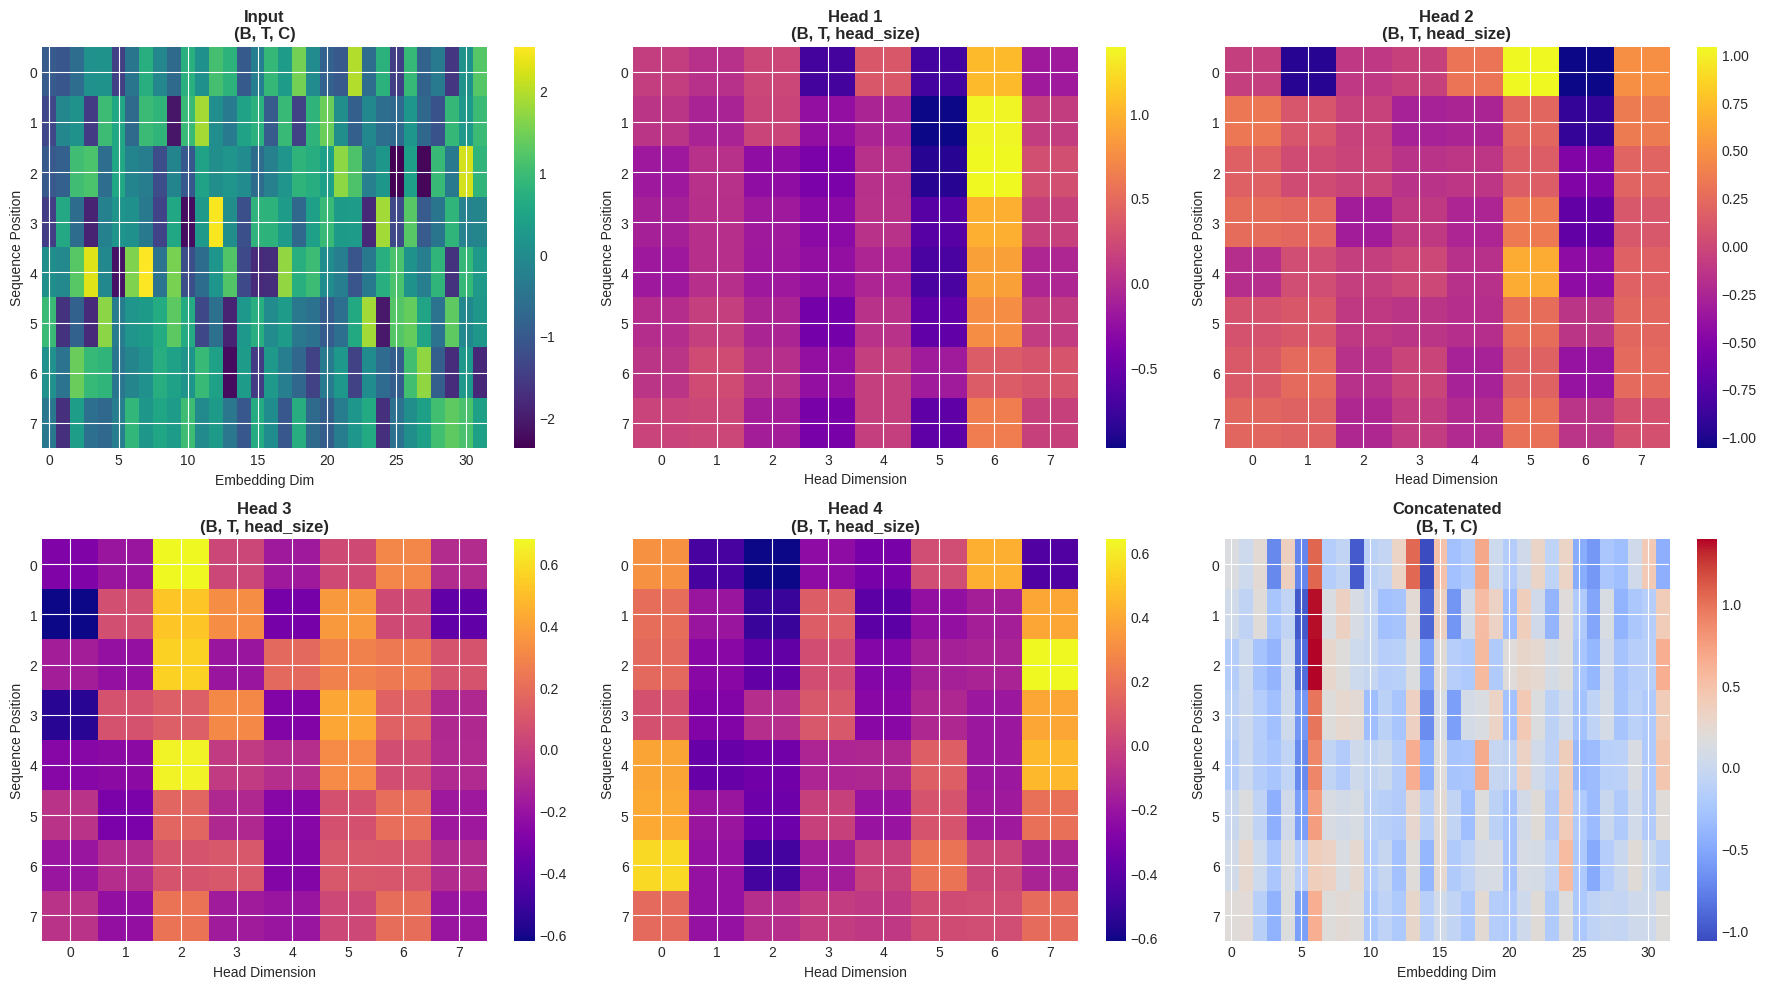


💡 Each head processes the input independently, then outputs are concatenated


In [33]:
# Visualize multi-head attention process
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Input
im0 = axes[0, 0].imshow(x[0].detach().numpy(), cmap='viridis', aspect='auto')
axes[0, 0].set_title('Input\n(B, T, C)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Sequence Position')
axes[0, 0].set_xlabel('Embedding Dim')
plt.colorbar(im0, ax=axes[0, 0])

# Individual heads
for i in range(min(4, num_heads)):
    row = (i + 1) // 3
    col = (i + 1) % 3
    im = axes[row, col].imshow(head_outputs[i][0].detach().numpy(), cmap='plasma', aspect='auto')
    axes[row, col].set_title(f'Head {i+1}\n(B, T, head_size)', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('Sequence Position')
    axes[row, col].set_xlabel('Head Dimension')
    plt.colorbar(im, ax=axes[row, col])

# Concatenated
im_cat = axes[1, 2].imshow(concatenated[0].detach().numpy(), cmap='coolwarm', aspect='auto')
axes[1, 2].set_title('Concatenated\n(B, T, C)', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Sequence Position')
axes[1, 2].set_xlabel('Embedding Dim')
plt.colorbar(im_cat, ax=axes[1, 2])

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/embeddings/multi_head_process.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Each head processes the input independently, then outputs are concatenated")

---

## 5. Complete Multi-Head Attention

Let's implement the complete Multi-Head Attention layer:

In [34]:
class MultiHeadAttention(nn.Module):
    """
    Multiple heads of self-attention in parallel.
    
    Args:
        n_embd: Embedding dimension
        num_heads: Number of attention heads
        block_size: Maximum sequence length
        dropout: Dropout probability
    """
    
    def __init__(self, n_embd, num_heads, block_size, dropout=0.1):
        super().__init__()
        assert n_embd % num_heads == 0, "n_embd must be divisible by num_heads"
        
        self.num_heads = num_heads
        self.head_size = n_embd // num_heads
        
        # Create multiple attention heads
        self.heads = nn.ModuleList([
            SelfAttentionHead(n_embd, self.head_size, block_size, dropout)
            for _ in range(num_heads)
        ])
        
        # Output projection
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        """
        Args:
            x: Input embeddings, shape (B, T, C)
        
        Returns:
            out: Multi-head attention output, shape (B, T, C)
        """
        # Run all heads in parallel and concatenate
        out = torch.cat([head(x) for head in self.heads], dim=-1)
        
        # Apply output projection
        out = self.proj(out)
        out = self.dropout(out)
        
        return out

# Create multi-head attention
mha = MultiHeadAttention(n_embd, num_heads, block_size)

print(f"🎭 Multi-Head Attention Created!")
print(f"\n📊 Configuration:")
print(f"   Embedding dim:   {n_embd}")
print(f"   Number of heads: {num_heads}")
print(f"   Head size:       {n_embd // num_heads}")
print(f"   Block size:      {block_size}")

# Count parameters
total_params = sum(p.numel() for p in mha.parameters())
print(f"\n💾 Total parameters: {total_params:,}")

🎭 Multi-Head Attention Created!

📊 Configuration:
   Embedding dim:   32
   Number of heads: 4
   Head size:       8
   Block size:      8

💾 Total parameters: 4,128


In [35]:
# Test multi-head attention
test_input = torch.randn(4, 8, n_embd)
test_output = mha(test_input)

print(f"📥 Input shape:  {test_input.shape}")
print(f"📤 Output shape: {test_output.shape}")
print(f"\n✅ Multi-head attention preserves shape: (B, T, C) → (B, T, C)")

📥 Input shape:  torch.Size([4, 8, 32])
📤 Output shape: torch.Size([4, 8, 32])

✅ Multi-head attention preserves shape: (B, T, C) → (B, T, C)


---

## 6. Attention Pattern Visualization

Let's visualize what different heads learn:

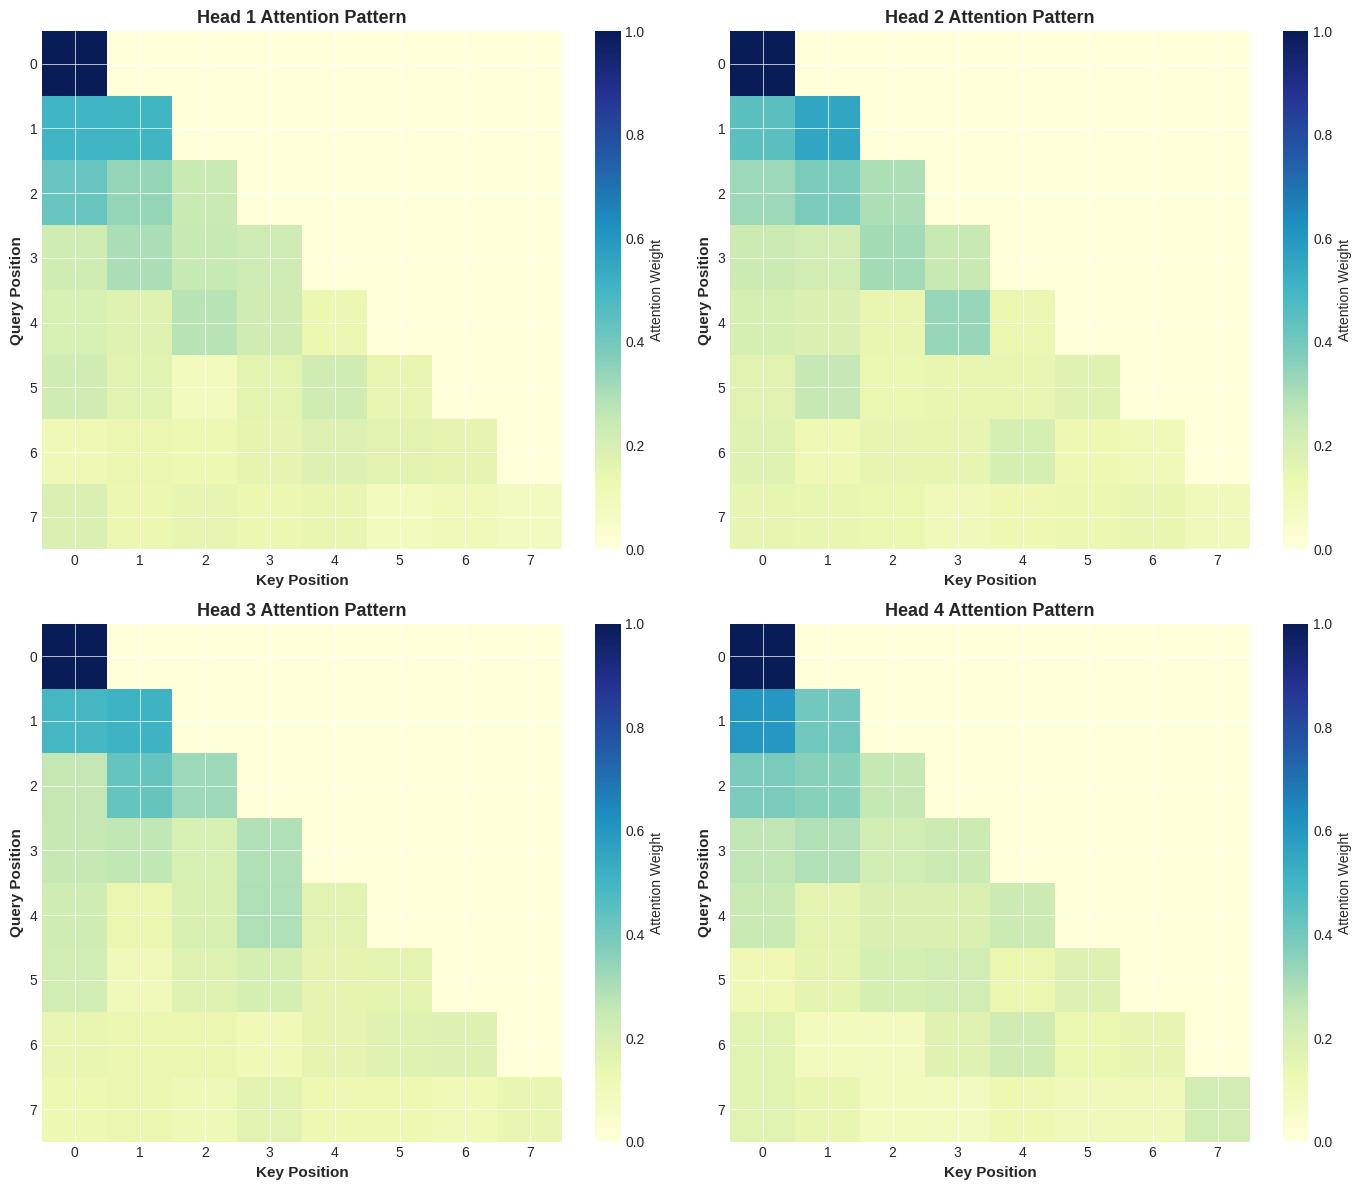


💡 Different heads learn different attention patterns!
   - Some heads may focus on nearby tokens
   - Others may focus on specific positions
   - Each head specializes in different relationships


In [36]:
# Extract attention patterns from each head
with torch.no_grad():
    x_test = torch.randn(1, 8, n_embd)
    
    attention_patterns = []
    for head in mha.heads:
        k = head.key(x_test)
        q = head.query(x_test)
        
        wei = q @ k.transpose(-2, -1) / (head.head_size ** 0.5)
        wei = wei.masked_fill(head.tril[:8, :8] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        
        attention_patterns.append(wei[0].numpy())

# Visualize all heads
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (ax, pattern) in enumerate(zip(axes, attention_patterns)):
    im = ax.imshow(pattern, cmap='YlGnBu', aspect='auto', vmin=0, vmax=1)
    ax.set_xlabel('Key Position', fontsize=11, fontweight='bold')
    ax.set_ylabel('Query Position', fontsize=11, fontweight='bold')
    ax.set_title(f'Head {i+1} Attention Pattern', fontsize=13, fontweight='bold')
    ax.grid(which='both', color='white', linewidth=0.5)
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Attention Weight')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/embeddings/multi_head_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Different heads learn different attention patterns!")
print("   - Some heads may focus on nearby tokens")
print("   - Others may focus on specific positions")
print("   - Each head specializes in different relationships")

### 📊 Compare Head Behaviors

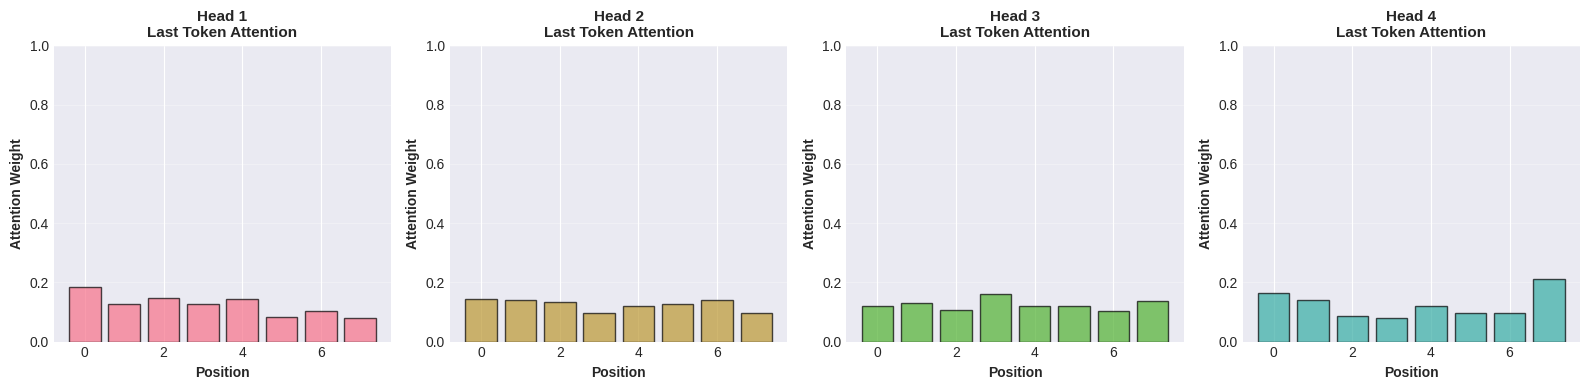


💡 Each head has a different attention distribution!


In [37]:
# Analyze attention distribution for each head
fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))

for i, (ax, pattern) in enumerate(zip(axes, attention_patterns)):
    # Get attention weights for the last token (most context)
    last_token_attention = pattern[-1, :]
    
    ax.bar(range(len(last_token_attention)), last_token_attention, 
           color=f'C{i}', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Position', fontsize=10, fontweight='bold')
    ax.set_ylabel('Attention Weight', fontsize=10, fontweight='bold')
    ax.set_title(f'Head {i+1}\nLast Token Attention', fontsize=11, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/embeddings/head_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Each head has a different attention distribution!")

---

## 7. Computational Analysis

### 📊 Parameter Count

In [38]:
# Analyze parameters
print("📊 Parameter Breakdown:")
print("=" * 60)

# Per head
head_params = sum(p.numel() for p in mha.heads[0].parameters())
print(f"\nPer Head:")
print(f"   Q projection: {n_embd} × {n_embd // num_heads} = {n_embd * (n_embd // num_heads):,}")
print(f"   K projection: {n_embd} × {n_embd // num_heads} = {n_embd * (n_embd // num_heads):,}")
print(f"   V projection: {n_embd} × {n_embd // num_heads} = {n_embd * (n_embd // num_heads):,}")
print(f"   Total per head: {head_params:,}")

# All heads
all_heads_params = head_params * num_heads
print(f"\nAll {num_heads} Heads: {all_heads_params:,}")

# Output projection
proj_params = n_embd * n_embd
print(f"\nOutput Projection: {n_embd} × {n_embd} = {proj_params:,}")

# Total
print(f"\n{'='*60}")
print(f"Total Parameters: {total_params:,}")
print(f"{'='*60}")

📊 Parameter Breakdown:

Per Head:
   Q projection: 32 × 8 = 256
   K projection: 32 × 8 = 256
   V projection: 32 × 8 = 256
   Total per head: 768

All 4 Heads: 3,072

Output Projection: 32 × 32 = 1,024

Total Parameters: 4,128


### ⚡ Computational Complexity

In [39]:
# Analyze computational complexity
T = block_size  # Sequence length
d = n_embd      # Embedding dimension
h = num_heads   # Number of heads
d_h = d // h    # Head dimension

print("⚡ Computational Complexity Analysis:")
print("=" * 60)

print(f"\nGiven:")
print(f"   Sequence length (T): {T}")
print(f"   Embedding dim (d):   {d}")
print(f"   Number of heads (h): {h}")
print(f"   Head size (d/h):     {d_h}")

print(f"\nPer Head:")
print(f"   Q, K, V projections: O(T × d × d_h) = O({T} × {d} × {d_h})")
print(f"   Attention scores:    O(T² × d_h) = O({T}² × {d_h})")
print(f"   Weighted sum:        O(T² × d_h) = O({T}² × {d_h})")

print(f"\nAll Heads:")
print(f"   Total: h × O(T² × d_h) = O(T² × d)")

print(f"\nOutput Projection:")
print(f"   O(T × d²) = O({T} × {d}²)")

print(f"\n💡 Key Insight:")
print(f"   Multi-head attention has the SAME complexity as single-head!")
print(f"   We split d into h heads of size d/h, so:")
print(f"   h × (T² × d/h) = T² × d")
print(f"\n   But we get {h}× more expressive power!")

⚡ Computational Complexity Analysis:

Given:
   Sequence length (T): 8
   Embedding dim (d):   32
   Number of heads (h): 4
   Head size (d/h):     8

Per Head:
   Q, K, V projections: O(T × d × d_h) = O(8 × 32 × 8)
   Attention scores:    O(T² × d_h) = O(8² × 8)
   Weighted sum:        O(T² × d_h) = O(8² × 8)

All Heads:
   Total: h × O(T² × d_h) = O(T² × d)

Output Projection:
   O(T × d²) = O(8 × 32²)

💡 Key Insight:
   Multi-head attention has the SAME complexity as single-head!
   We split d into h heads of size d/h, so:
   h × (T² × d/h) = T² × d

   But we get 4× more expressive power!


### 📈 Memory Usage

In [40]:
# Calculate memory usage
B = 4  # Batch size

print("📈 Memory Usage (per forward pass):")
print("=" * 60)

# Input
input_mem = B * T * d * 4 / (1024**2)  # 4 bytes per float32
print(f"\nInput: (B={B}, T={T}, d={d})")
print(f"   {input_mem:.2f} MB")

# Attention scores (per head)
attn_mem_per_head = B * T * T * 4 / (1024**2)
attn_mem_total = attn_mem_per_head * h
print(f"\nAttention Scores: (B={B}, T={T}, T={T}) × {h} heads")
print(f"   Per head: {attn_mem_per_head:.2f} MB")
print(f"   Total:    {attn_mem_total:.2f} MB")

# Output
output_mem = B * T * d * 4 / (1024**2)
print(f"\nOutput: (B={B}, T={T}, d={d})")
print(f"   {output_mem:.2f} MB")

# Total
total_mem = input_mem + attn_mem_total + output_mem
print(f"\n{'='*60}")
print(f"Approximate Total: {total_mem:.2f} MB")
print(f"{'='*60}")

print(f"\n💡 The T² term in attention scores dominates for long sequences!")

📈 Memory Usage (per forward pass):

Input: (B=4, T=8, d=32)
   0.00 MB

Attention Scores: (B=4, T=8, T=8) × 4 heads
   Per head: 0.00 MB
   Total:    0.00 MB

Output: (B=4, T=8, d=32)
   0.00 MB

Approximate Total: 0.01 MB

💡 The T² term in attention scores dominates for long sequences!


---

## 8. Key Takeaways

### ✅ What We Learned

1. **Why Multiple Heads?**
   - Single head learns one attention pattern
   - Multiple heads learn diverse patterns
   - Each head can specialize (syntax, semantics, position, etc.)
   - Ensemble of perspectives

2. **Architecture**
   ```
   Input (B, T, d)
      ↓
   Split into h heads
      ↓
   Head 1: (B, T, d/h)
   Head 2: (B, T, d/h)
   ...
   Head h: (B, T, d/h)
      ↓
   Concatenate: (B, T, d)
      ↓
   Project: (B, T, d)
   ```

3. **Key Operations**
   - **Parallel Processing**: All heads run simultaneously
   - **Concatenation**: Combine head outputs
   - **Output Projection**: Mix information from all heads

4. **Computational Efficiency**
   - Same complexity as single-head: O(T² × d)
   - But h× more expressive power
   - Clever use of parallelism

5. **Attention Patterns**
   - Different heads learn different patterns
   - Some focus on local context
   - Others capture long-range dependencies
   - Diversity improves model capacity

### 🎯 Key Insights

- **Ensemble Learning**: Multiple heads = multiple perspectives
- **Specialization**: Each head can focus on different aspects
- **Efficiency**: No extra computational cost vs single head
- **Flexibility**: Number of heads is a hyperparameter

### 🔮 What's Next?

In **Notebook 7**, we'll implement **Feed-Forward Networks**:
- Position-wise transformations
- Non-linearity and capacity
- The "thinking" component of Transformers
- Combining attention with feed-forward layers!

In [41]:
# Save multi-head attention
torch.save({
    'multi_head_attention': mha.state_dict(),
    'n_embd': n_embd,
    'num_heads': num_heads,
    'block_size': block_size
}, f'{DATA_DIR}/multi_head_attention.pth')

print("✅ Multi-head attention saved to f'{DATA_DIR}/multi_head_attention.pth'")

✅ Multi-head attention saved to f'{DATA_DIR}/multi_head_attention.pth'
